In [5]:
#Train-validate-test no hyperparameter tuning
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    cohen_kappa_score, f1_score
)

# 1. Load CSV with Thai encoding
df = pd.read_csv("../csvs/2020_2024_for_small_class.csv", encoding="utf-8-sig")
df_clean = df.dropna()

X = df_clean.drop(columns=['Unnamed: 0','label'])
y = df_clean['label']

# ---- Split 80:10:10 ----
# First split 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split 20% temp into 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

# ---- Define your own RandomForest parameters ----
best_rf = RandomForestClassifier(
    n_estimators=254,        # number of trees
    max_depth=36,            # tree depth
    min_samples_split=5,     # min samples to split
    min_samples_leaf=1,      # min samples per leaf
    max_features='log2',     # features considered at each split
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ---- Train on training set ----
best_rf.fit(X_train, y_train)

# ---- Evaluate on validation set ----
y_val_pred = best_rf.predict(X_val)
print("\n--- Validation Performance ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Kappa:", cohen_kappa_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred, average='weighted'))
print("Precision:", precision_score(y_val, y_val_pred, average='weighted'))
print("Recall:", recall_score(y_val, y_val_pred, average='weighted'))

# ---- Final Test Evaluation ----
y_test_pred = best_rf.predict(X_test)
print("\n--- Test Performance ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Kappa:", cohen_kappa_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred, average='weighted'))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))


Train size: (2431575, 15)
Validation size: (303947, 15)
Test size: (303947, 15)

--- Validation Performance ---
Accuracy: 0.717358618443347
Kappa: 0.6794538405876523
F1: 0.7155041530230564
Precision: 0.7272677138024756
Recall: 0.717358618443347

--- Test Performance ---
Accuracy: 0.7156806943315775
Kappa: 0.6775283104222374
F1: 0.7139114452528666
Precision: 0.7260433791432861
Recall: 0.7156806943315775


    Feature  Importance
1    evi 10    0.080355
14  swir 12    0.079039
9   swir 11    0.076195
2   ndwi 10    0.072941
4   swir 10    0.069215
12  ndwi 12    0.068637
7   ndwi 11    0.068613


C:\Users\Gunn\AppData\Local\Temp\ipykernel_23344\4136654474.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")


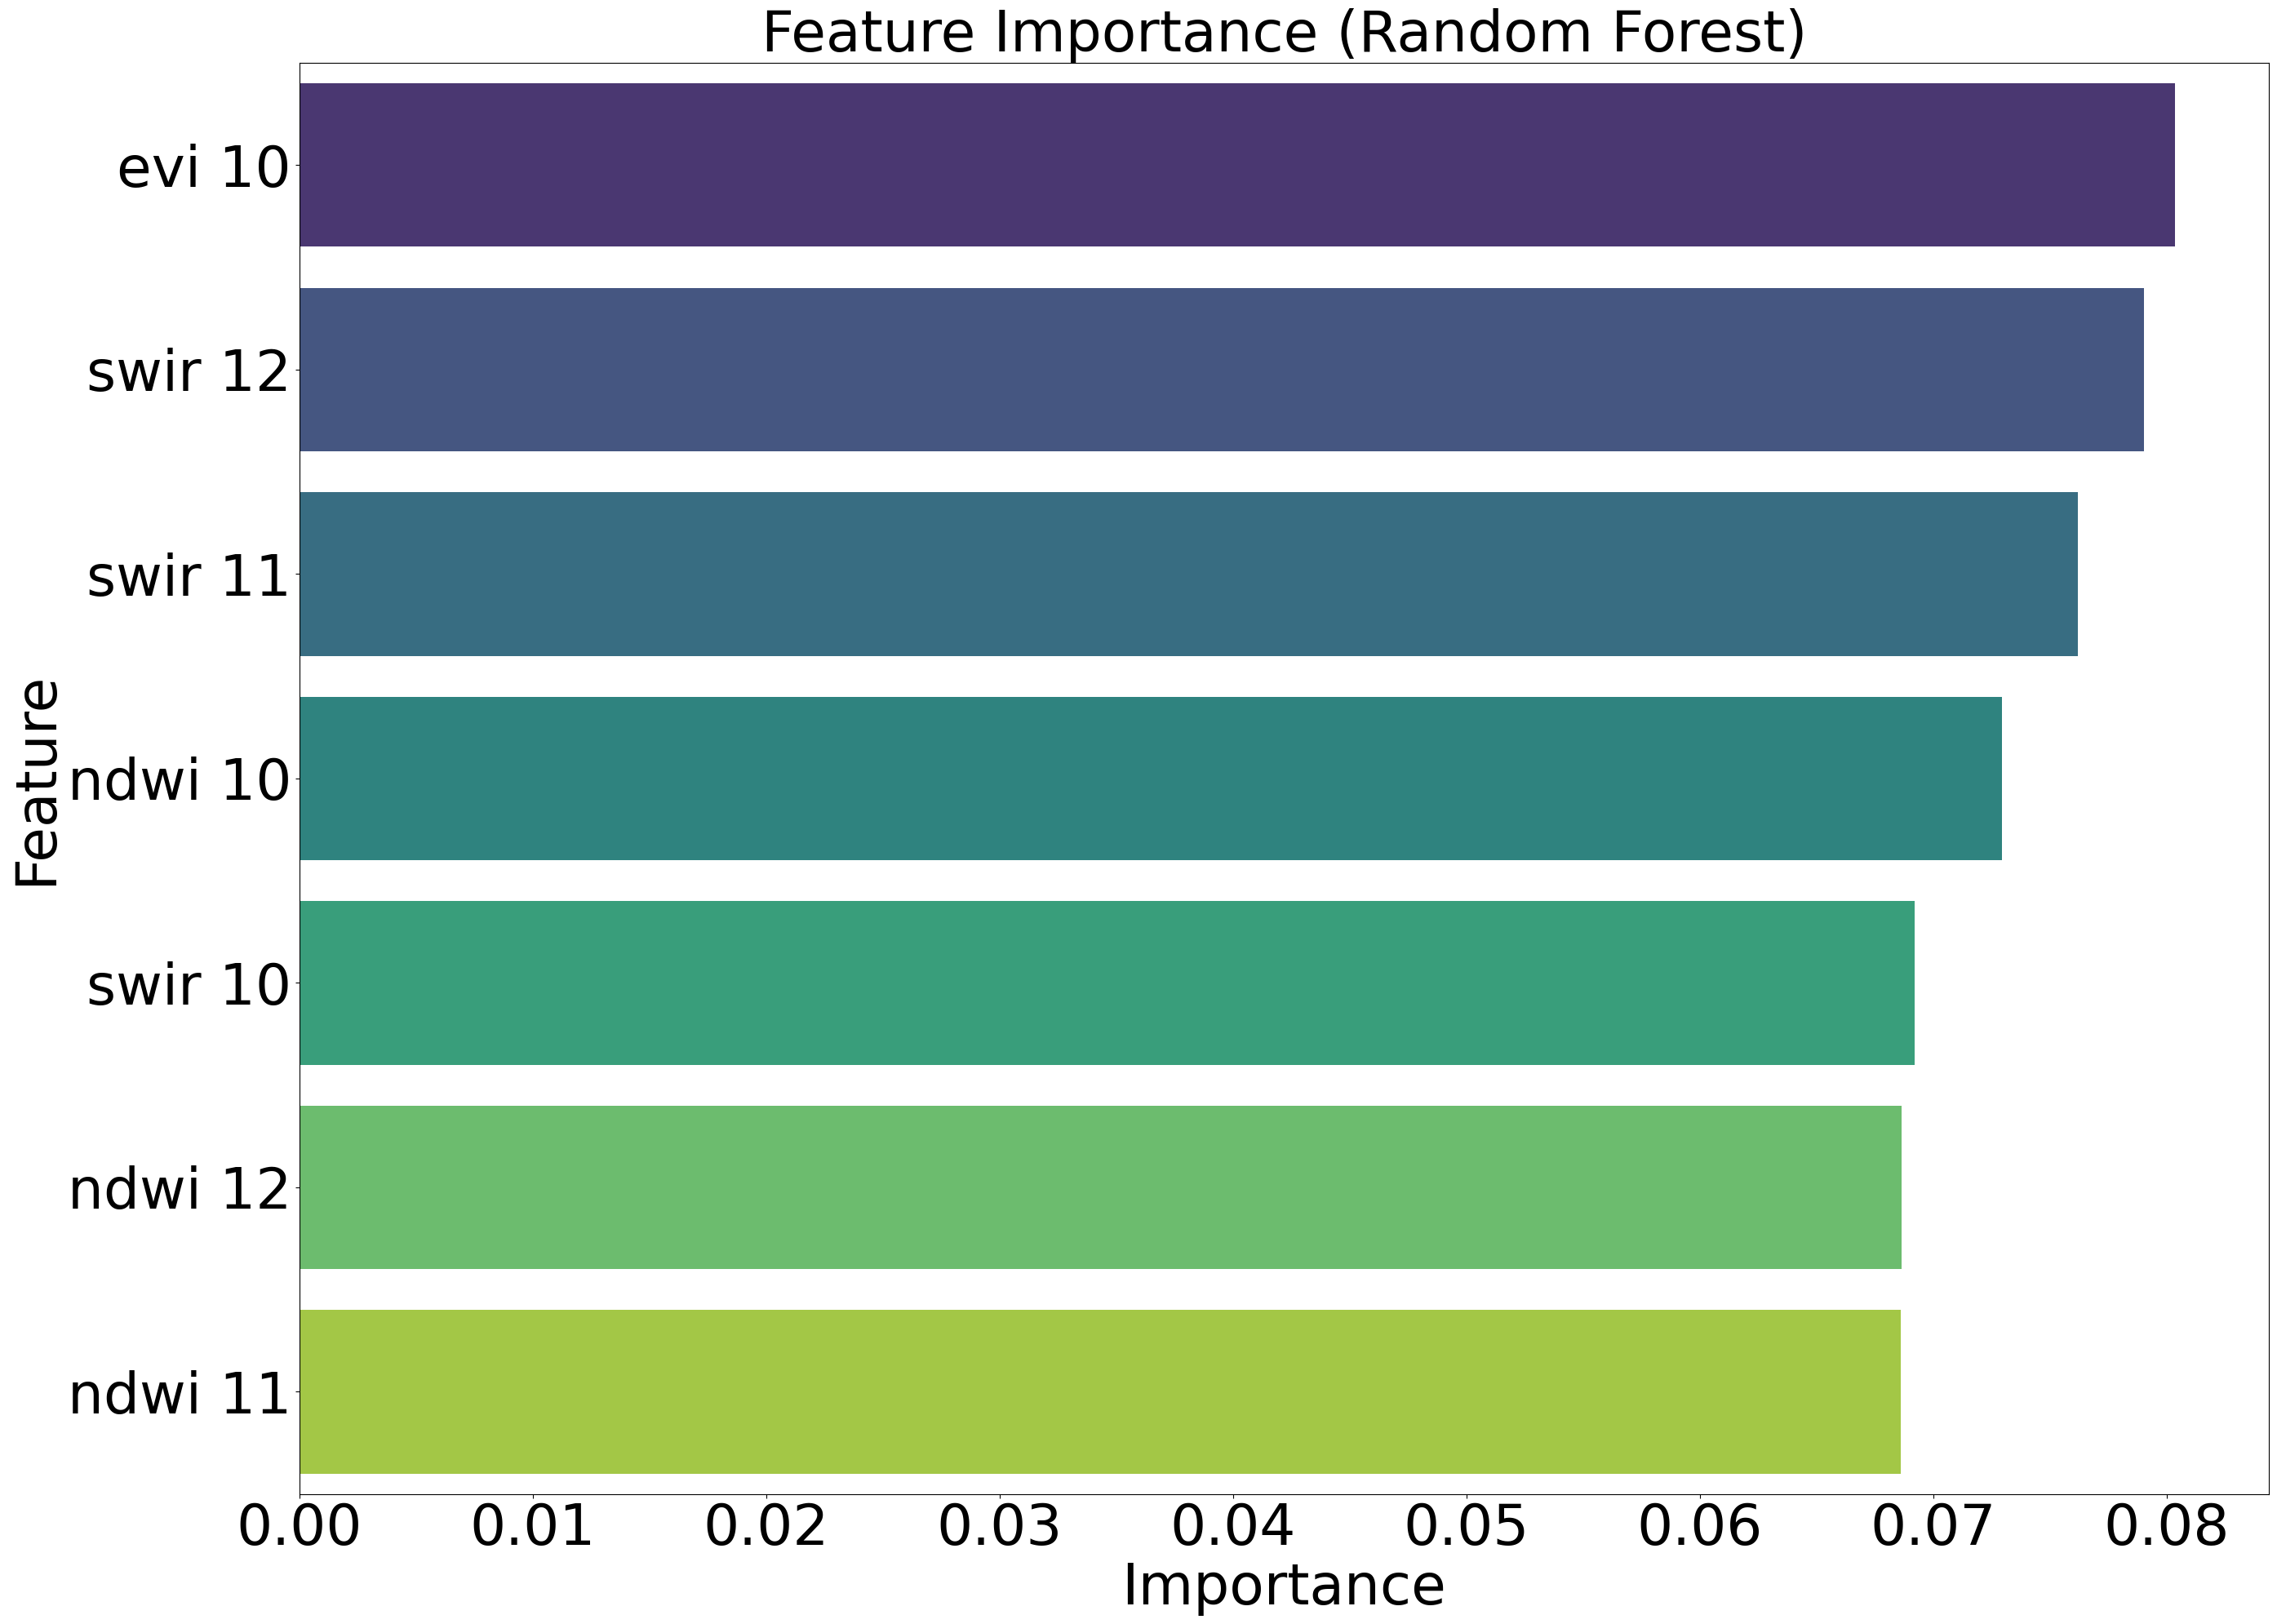

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = best_rf.feature_importances_

# Put into a DataFrame for easy viewing
feat_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(7)

print(feat_importances)

# Plot feature importance
plt.figure(figsize=(28, 20))
sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")
plt.title("Feature Importance (Random Forest)", fontsize=50)
plt.xlabel("Importance", fontsize=50)
plt.ylabel("Feature", fontsize=50)

plt.xticks(fontsize=50)
plt.yticks(fontsize=50)

plt.tight_layout()
plt.show()